In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pickle
import sys
sys.path.append(r'C\Dell\Desktop\Projects\Credit Risk Scorecard & Portfolio Risk Assessment')

with open(r'C:\Users\Dell\Desktop\Projects\Credit Risk Scorecard & Portfolio Risk Assessment\xgb_model.pkl', 'rb') as f:
    model= pickle.load(f)

data= pd.read_csv(r'C:\Users\Dell\Desktop\Projects\Credit Risk SCorecard & Portfolio Risk Assessment\application_train.csv')
print(data.shape)

(307511, 122)


In [3]:
null_pct= data.isna().sum() / len(data) *100
cols_to_drop= null_pct[null_pct > 40].index
data= data.drop(columns= cols_to_drop)

for col in data.columns:
    if data[col].dtype== 'object':
        data[col].fillna(data[col].mode()[0], inplace= True)
    else:
        data[col].fillna(data[col].median(), inplace= True)

from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
for col in data.select_dtypes(include= 'object').columns:
    data[col]= le.fit_transform(data[col].astype(str))

data['AGE']= data['DAYS_BIRTH'] / -365
data.drop(columns= ['DAYS_BIRTH'], inplace= True)

for col in ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']:
    data[col]= np.log1p(data[col])

print('Cleaning Done', data.shape)

Cleaning Done (307511, 73)


In [4]:
selected_features= ['EXT_SOURCE_2', 'AMT_ANNUITY', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'AMT_CREDIT', 'AGE', 'AMT_INCOME_TOTAL', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_3', 'AMT_GOODS_PRICE', 'DAYS_LAST_PHONE_CHANGE', 'REGION_POPULATION_RELATIVE', 'ORGANIZATION_TYPE', 'NAME_INCOME_TYPE', 'REGION_RATING_CLIENT_W_CITY', 'NAME_EDUCATION_TYPE', 'OCCUPATION_TYPE', 'REGION_RATING_CLIENT', 'CODE_GENDER', 'FLAG_EMP_PHONE', 'REG_CITY_NOT_WORK_CITY', 'FLAG_DOCUMENT_3', 'REG_CITY_NOT_LIVE_CITY', 'NAME_FAMILY_STATUS']

X= data[selected_features]
data['PD']= model.predict_proba(X)[:, 1]

print(data['PD'].describe())

count    307511.000000
mean          0.403206
std           0.198286
min           0.007133
25%           0.241890
50%           0.378074
75%           0.547652
max           0.959257
Name: PD, dtype: float64


In [5]:
data['LOAN_ID']= range(len(data))
data['EAD']= np.expm1(data['AMT_CREDIT'])
data['LGD']= 0.45

data['EL']= data['PD'] * data['LGD'] * data['EAD']

print(f"Total Portfolio EAD: ${data['EAD'].sum():,.0f}")
print(f"Total Expected Loss: ${data['EL'].sum():,.0f}")
print(f"EL as % of Portfolio: {data['EL'].sum() / data['EAD'].sum()*100:,.2f}%")

Total Portfolio EAD: $184,207,084,196
Total Expected Loss: $32,077,301,876
EL as % of Portfolio: 17.41%


In [6]:
np.random.seed(42)
n_simulations= 10000
n_loans= len(data)
rho= 0.15

portfolio_losses= []

for _ in range(n_simulations):
    Z= np.random.normal(0,1)
    eps= np.random.normal(0, 1, n_loans)
    asset_returns= np.sqrt(rho)*Z + np.sqrt(1-rho)*eps
    threshold= stats.norm.ppf(data['PD'].values)
    defaults= asset_returns < threshold
    loss= (defaults*data['LGD']*data['EAD']).sum()
    portfolio_losses.append(loss)

portfolio_losses= np.array(portfolio_losses)
print(f"Mean Loss: ${np.mean(portfolio_losses):,.0f}")
print(f"VaR 95%: ${np.percentile(portfolio_losses, 95):,.0f}")
print(f"VaR 99%: ${np.percentile(portfolio_losses, 99):,.0f}")


Mean Loss: $32,118,211,990
VaR 95%: $50,821,458,112
VaR 99%: $58,232,999,367


In [7]:
economic_capital_95= np.percentile(portfolio_losses, 95) - np.mean(portfolio_losses)
economic_capital_99= np.percentile(portfolio_losses, 99) - np.mean(portfolio_losses)

print(f"Economic Capital 95%: ${economic_capital_95:,.0f}")
print(f"Economic Capital 99%: ${economic_capital_99:,.0f}")

Economic Capital 95%: $18,703,246,122
Economic Capital 99%: $26,114,787,377


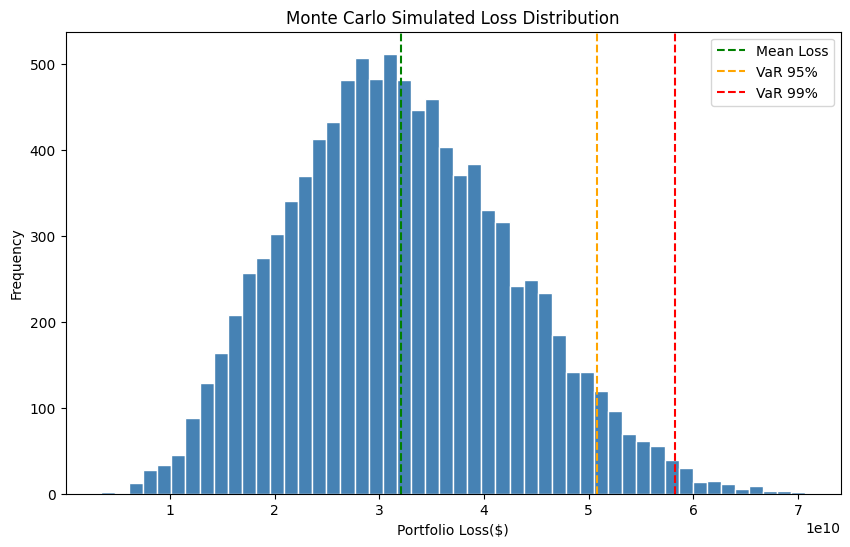

In [8]:
plt.figure(figsize=(10,6))
plt.hist(portfolio_losses, bins= 50, color= 'steelblue', edgecolor= 'white')

plt.axvline(np.mean(portfolio_losses), color= 'green', linestyle= '--', label= 'Mean Loss')
plt.axvline(np.percentile(portfolio_losses, 95), color= 'orange', linestyle= '--', label= 'VaR 95%')
plt.axvline(np.percentile(portfolio_losses, 99), color= 'red', linestyle= '--', label= 'VaR 99%')
            
plt.xlabel('Portfolio Loss($)')
plt.ylabel('Frequency')
plt.title('Monte Carlo Simulated Loss Distribution')
plt.legend()
plt.show()


In [9]:
data['approx_yield']= (data['AMT_ANNUITY']*12 - data['AMT_CREDIT'])/ data['AMT_CREDIT']
data['approx_yield'].describe()

count    307511.000000
mean          8.247943
std           0.283629
min           7.274462
25%           8.029307
50%           8.212351
75%           8.420267
max           9.150539
Name: approx_yield, dtype: float64

In [10]:
'CNT_PAYMENT' in data.columns

False

In [11]:
data.columns[data.columns.str.contains('TERM|DURATION|PAYMENT', case= False)]

Index([], dtype='object')

In [12]:
data['approx_yield']= data['NAME_CONTRACT_TYPE'].map({'Cash loans': 0.15, 'Revolving loans': 0.24})

data['net_yield']= data['approx_yield'] - (data['PD']*data['LGD'])

data[['NAME_CONTRACT_TYPE', 'approx_yield', 'net_yield']].describe()

,NAME_CONTRACT_TYPE,approx_yield,net_yield
count,307511.000000,0.0,0.0
mean,0.095213,NaN,NaN
std,0.293509,NaN,NaN
min,0.000000,NaN,NaN
25%,0.000000,NaN,NaN
50%,0.000000,NaN,NaN
75%,0.000000,NaN,NaN
max,1.000000,NaN,NaN


In [13]:
data['NAME_CONTRACT_TYPE'].unique()

array([0, 1])

In [14]:
data['approx_yield']= data['NAME_CONTRACT_TYPE'].map({0:0.15, 1:0.24})
data.groupby('NAME_CONTRACT_TYPE')['AMT_CREDIT'].mean()

NAME_CONTRACT_TYPE
0    13.127536
1    12.524379
Name: AMT_CREDIT, dtype: float64

In [15]:
data['net_yield']= data['approx_yield'] - (data['PD']*data['LGD'])
data[['NAME_CONTRACT_TYPE', 'approx_yield', 'net_yield']].describe()
data['approx_yield'].isnull().sum()


np.int64(0)

In [16]:
frontier_data= data.groupby('NAME_INCOME_TYPE').agg(
    mean_PD= ('PD', 'mean'),
    mean_net_yield= ('net_yield', 'mean'),
    count= ('PD', 'size')
).reset_index()

frontier_data= frontier_data[frontier_data['count'] > 100]
frontier_data

,NAME_INCOME_TYPE,mean_PD,mean_net_yield,count
1,1,0.388184,-0.014674,71617
3,3,0.328271,0.007755,55362
4,4,0.340176,0.004663,21703
7,7,0.444736,-0.041030,158774


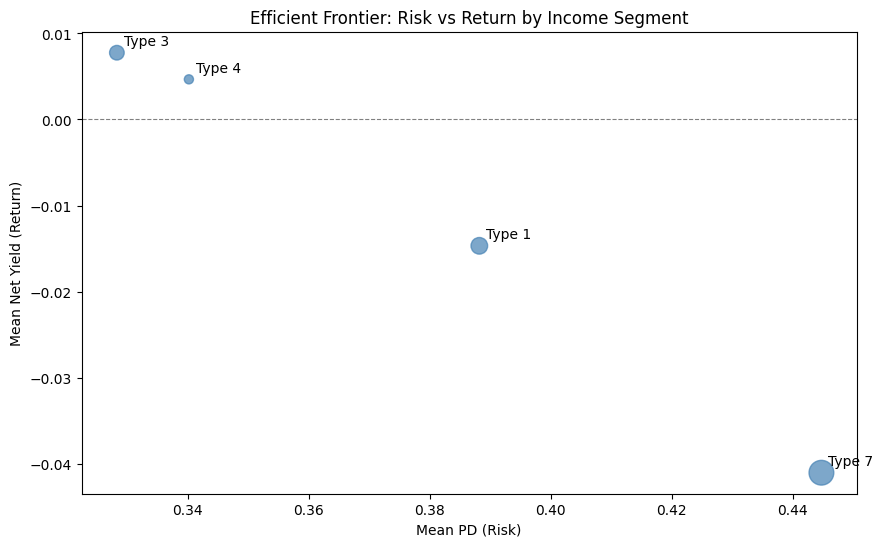

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(frontier_data['mean_PD'], frontier_data['mean_net_yield'],
           s= frontier_data['count']/500, alpha= 0.7, color= 'steelblue')

for _, row in frontier_data.iterrows():
    plt.annotate(f"Type {int(row['NAME_INCOME_TYPE'])}",
                (row['mean_PD'], row['mean_net_yield']),
                textcoords= "offset points", xytext= (5,5))

plt.xlabel('Mean PD (Risk)')
plt.ylabel('Mean Net Yield (Return)')
plt.title('Efficient Frontier: Risk vs Return by Income Segment')
plt.axhline(0, color='gray', linestyle='--', linewidth= 0.8)
plt.show()

In [18]:
import os
os.environ["ANTHROPIC_API_KEY"]= os.getenv("ANTHROPIC_API_KEY", "") 

import anthropic
client= anthropic.Anthropic()

summary_input= frontier_data.to_dict('records')

response= client.messages.create(
    model= "claude-sonnet-4-6",
    max_tokens= 500,
    messages= [{
        "role" : "user",
        "content": f"Given this credit portfolio risk_return data by income segment: {summary_input}, write a 3-paragraph risk assessment summary in banking analyst language, covering which segments are profitable under current pricing assumptions and what that implies for portfolio strategy."
    }]
)

risk_narrative= response.content[0].text
print(risk_narrative)
         

# Credit Portfolio Risk Assessment: Income Segment Analysis

---

## Executive Summary

Analysis of the current credit portfolio across four income segments reveals materially divergent risk-return profiles, with two of the four segments generating negative net yield under prevailing pricing assumptions, raising significant concerns about portfolio-wide profitability and risk-adjusted return optimization. Segment 3 demonstrates the most favorable risk-return dynamic, posting a mean probability of default (PD) of 32.8% alongside a positive net yield of approximately 77.5 basis points, representing the sole high-conviction profitable segment at meaningful scale with 55,362 obligors. Segment 4 similarly generates positive, albeit compressed, net yield of approximately 46.6 basis points against a mean PD of 34.0% across 21,703 accounts, suggesting marginal but technically viable risk-adjusted economics under current spread assumptions. Critically, these two profitable segments together rep

In [19]:
np.save('portfolio_losses.npy', portfolio_losses)
frontier_data.to_csv('frontier_data.csv', index= False)
with open('risk_narrative.txt', 'w') as f:
    f.write(risk_narrative)

print('Artifacts saved.')

Artifacts saved.
